# SINAN Dengue Pipeline — Step by Step

Case-level SINAN CSVs → weekly case series, one step at a time.

Mirrors `src/pipeline/sinan/` exactly — this notebook just unrolls `build_year()`
so each transformation is visible. Runs on the committed fixtures in
`tests/fixtures/sinan/` (small stratified samples, one per schema tier), so it
executes in seconds instead of minutes on the real ~7 GB input.

**Pipeline:** scan → ensure columns → parse dates → filter consistency → epiweeks → normalise keys → aggregate → merge years → attach state → order


## Setup

In [1]:
import sys
from pathlib import Path

import polars as pl

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT / "src"))

from pipeline.sinan.spec import DENGUE, DATE_COLUMNS, EPIWEEK_OF
from pipeline.sinan.steps import (
    scan_year, ensure_columns, parse_dates, filter_date_consistency,
    add_epiweeks, normalise_keys, aggregate, merge_years, attach_state,
    order_columns, load_federative_units, build_year,
    DEFAULT_DIF_LOWER, DEFAULT_DIF_UPPER,
)

pl.Config.set_tbl_rows(8)

FIXTURES = PROJECT_ROOT / "tests" / "fixtures" / "sinan"
FU_PATH = PROJECT_ROOT / "data" / "epidemiological" / "br_federative_units.csv"

# One fixture per schema tier: 2013 (has DT_DIGITA), 2016 (missing it),
# 2020 (declared but empty), 2022 (has it again).
YEARS = [2013, 2016, 2020, 2022]
paths = {y: FIXTURES / f"DENGBR{y % 100:02d}.csv.gz" for y in YEARS}
paths


{2013: PosixPath('/home/caioolubini/Projects/dengue-data-collection/tests/fixtures/sinan/DENGBR13.csv.gz'),
 2016: PosixPath('/home/caioolubini/Projects/dengue-data-collection/tests/fixtures/sinan/DENGBR16.csv.gz'),
 2020: PosixPath('/home/caioolubini/Projects/dengue-data-collection/tests/fixtures/sinan/DENGBR20.csv.gz'),
 2022: PosixPath('/home/caioolubini/Projects/dengue-data-collection/tests/fixtures/sinan/DENGBR22.csv.gz')}

## Step 1 — Scan a year, project columns only

`scan_year` opens a lazy CSV handle and projects down to 5 raw columns out of
SINAN's 66–121. This projection is the entire memory story: the reader never
parses the columns we drop.

Dates come in as strings — a strict date type would reject SINAN's empty fields.


In [2]:
year = 2022
raw = scan_year(paths[year], year, DENGUE)
raw.collect_schema()


Schema([('DT_DIGITA', String),
        ('DT_NOTIFIC', String),
        ('DT_SIN_PRI', String),
        ('SG_UF_NOT', String),
        ('CLASSI_FIN', String)])

In [ ]:
raw.head(5).collect()

DT_DIGITA,DT_NOTIFIC,DT_SIN_PRI,SG_UF_NOT,CLASSI_FIN
str,str,str,str,str
null,"""2022-07-12""","""2022-07-11""","""32""","""10"""
null,"""2022-01-21""","""2022-01-17""","""32""","""10"""
null,"""2022-01-19""","""2022-01-17""","""32""","""10"""
null,"""2022-01-01""","""2021-12-29""","""32""","""10"""
null,"""2022-01-02""","""2022-01-01""","""32""","""10"""


## Step 2 — Ensure a common schema

Only `DT_DIGITA` varies across years (missing 2014–2020). `ensure_columns` fills
it with a typed null where absent, so every year concatenates safely later —
and so `ew_recorded` stays genuinely null rather than accidentally zero.


In [4]:
for y in YEARS:
    cols = scan_year(paths[y], y, DENGUE).collect_schema().names()
    print(f"{y}: DT_DIGITA present = {'DT_DIGITA' in cols}")


2013: DT_DIGITA present = True
2016: DT_DIGITA present = False
2020: DT_DIGITA present = False
2022: DT_DIGITA present = True


In [5]:
ensured = ensure_columns(raw, year, DENGUE)
ensured.head(3).collect()


DT_DIGITA,DT_NOTIFIC,DT_SIN_PRI,SG_UF_NOT,CLASSI_FIN
str,str,str,str,str
null,"""2022-07-12""","""2022-07-11""","""32""","""10"""
null,"""2022-01-21""","""2022-01-17""","""32""","""10"""
null,"""2022-01-19""","""2022-01-17""","""32""","""10"""


## Step 3 — Parse dates

`strict=False` turns unparseable strings into null instead of raising — SINAN
has empty and occasionally malformed date fields, same as the R pipeline's
silent `NA` coercion.


In [6]:
parsed = parse_dates(ensured)
parsed.head(5).collect()


DT_DIGITA,DT_NOTIFIC,DT_SIN_PRI,SG_UF_NOT,CLASSI_FIN
date,date,date,str,str
null,2022-07-12,2022-07-11,"""32""","""10"""
null,2022-01-21,2022-01-17,"""32""","""10"""
null,2022-01-19,2022-01-17,"""32""","""10"""
null,2022-01-01,2021-12-29,"""32""","""10"""
null,2022-01-02,2022-01-01,"""32""","""10"""


## Step 4 — Filter date consistency

Keeps `-180 < (onset − notification) < 1` days, both bounds strict. Drops:
- onsets recorded **more than 180 days before** notification (data-entry errors)
- onsets recorded **after** their own notification

Rows with a null date are dropped too — the comparison yields null and `filter`
keeps only `true`.


In [7]:
before = parsed.select(pl.len()).collect().item()
filtered = filter_date_consistency(parsed, DEFAULT_DIF_LOWER, DEFAULT_DIF_UPPER)
after = filtered.select(pl.len()).collect().item()
print(f"{before:,} -> {after:,} rows ({before - after:,} dropped)")


40,000 -> 39,989 rows (11 dropped)


## Step 5 — Floor dates to epidemiological weeks

Brazilian epi weeks run **Sunday → Saturday**. Each date is floored to the
Sunday that starts its week — a *date*, not a `YYYYWW` number.

⚠️ Not `dt.truncate("1w")`: polars anchors that on Monday, one day off from R's
`floor_date(unit="week")`. `floor_to_sunday` uses `weekday() % 7` instead.


In [8]:
weekly = add_epiweeks(filtered)
weekly.head(5).collect()


SG_UF_NOT,CLASSI_FIN,ew_recorded,ew_notification,ew_symptom_onset
str,str,date,date,date
"""32""","""10""",null,2022-07-10,2022-07-10
"""32""","""10""",null,2022-01-16,2022-01-16
"""32""","""10""",null,2022-01-16,2022-01-16
"""32""","""10""",null,2021-12-26,2021-12-26
"""32""","""10""",null,2022-01-02,2021-12-26


In [9]:
# sanity check: every non-null epiweek must land on a Sunday (isoweekday 7)
weekly.select(
    [pl.col(c).dt.weekday().is_in([7, None]).all().alias(c) for c in EPIWEEK_OF.values()]
).collect()


ew_recorded,ew_notification,ew_symptom_onset
bool,bool,bool
true,true,true


## Step 6 — Normalise keys

Casts `CLASSI_FIN` (final classification) and `SG_UF_NOT` (state code) from
string to integer. Empty classification becomes null — a legitimate
"not yet classified" state, kept as a group key rather than dropped.


In [10]:
normalised = normalise_keys(weekly)
normalised.head(5).collect()


SG_UF_NOT,ew_recorded,ew_notification,ew_symptom_onset,final_classification
i16,date,date,date,i8
32,null,2022-07-10,2022-07-10,10
32,null,2022-01-16,2022-01-16,10
32,null,2022-01-16,2022-01-16,10
32,null,2021-12-26,2021-12-26,10
32,null,2022-01-02,2021-12-26,10


## Step 7 — Aggregate to weekly counts

Collapses case-level rows into counts per (recorded week, notification week,
onset week, classification, state code). This is what makes the pipeline fit in
memory: millions of rows per year become a few hundred thousand.


In [11]:
aggregated = aggregate(normalised)
agg_df = aggregated.collect()
print(f"{normalised.select(pl.len()).collect().item():,} case rows -> {agg_df.height:,} grouped rows")
agg_df.head(5)


39,989 case rows -> 3,955 grouped rows


ew_recorded,ew_notification,ew_symptom_onset,final_classification,SG_UF_NOT,case_count
date,date,date,i8,i16,u32
2022-11-27,2022-11-20,2022-11-06,10,27,4
null,2022-05-15,2022-05-08,10,32,192
2022-04-17,2022-04-17,2022-03-20,10,12,1
2022-07-03,2022-06-05,2022-02-27,10,27,2
2022-06-26,2022-06-26,2022-06-26,10,27,33


## Step 8 — Build every year, then merge

`build_year()` composes steps 1–7 into one call per year. Years are processed
**one at a time** and collected immediately — no two raw years are ever
resident in memory together.

Then `merge_years` re-aggregates across the concatenated years: SINAN splits
the epi week spanning New Year's across two yearly files, so the same group key
can arrive twice before this step sums it back into one row.


In [12]:
yearly_frames = []
for y in YEARS:
    frame = build_year(paths[y], y, DENGUE).collect(engine="streaming")
    print(f"{y}: {frame.height:,} grouped rows")
    yearly_frames.append(frame)


2013: 5,383 grouped rows
2016: 1,976 grouped rows
2020: 1,182 grouped rows
2022: 3,955 grouped rows


In [13]:
combined = merge_years(pl.concat(yearly_frames, how="vertical").lazy())
combined.select(pl.len()).collect()


len
u32
12496


## Step 9 — Attach state abbreviation

Joins the numeric IBGE unit code (35) onto its abbreviation (SP) via
`br_federative_units.csv`. Inner join — unmapped codes are dropped, not nulled.


In [14]:
federative_units = load_federative_units(FU_PATH)
with_state = attach_state(combined, federative_units)
with_state.head(5).collect()


ew_recorded,ew_notification,ew_symptom_onset,final_classification,case_count,state_abbrev
date,date,date,i8,u32,str
2013-07-07,2013-05-26,2013-05-26,5,1,"""AL"""
2013-03-31,2013-03-17,2013-03-17,5,34,"""AM"""
null,2020-01-12,2019-12-22,10,9,"""AC"""
2013-12-08,2013-11-24,2013-11-24,1,7,"""AL"""
2013-05-19,2013-05-19,2013-05-12,5,12,"""AC"""


## Step 10 — Order columns, sort, done

Final published column order, sorted by state then the three epi weeks, nulls
last (polars and R disagree on default null ordering).


In [15]:
series = order_columns(with_state).collect()
print(f"final series: {series.height:,} rows x {series.width} columns")
series.head(10)


final series: 12,496 rows x 6 columns


ew_recorded,ew_notification,ew_symptom_onset,final_classification,state_abbrev,case_count
date,date,date,i8,str,u32
2012-12-30,2012-12-30,2012-12-16,1,"""AC""",3
2012-12-30,2012-12-30,2012-12-16,5,"""AC""",3
2012-12-30,2012-12-30,2012-12-23,1,"""AC""",28
2012-12-30,2012-12-30,2012-12-23,5,"""AC""",39
…,…,…,…,…,…
2012-12-30,2012-12-30,2012-12-30,null,"""AC""",4
2013-01-06,2012-12-30,2012-12-09,1,"""AC""",1
2013-01-06,2012-12-30,2012-12-16,1,"""AC""",6
2013-01-06,2012-12-30,2012-12-16,5,"""AC""",7


## Quick look — cases per week by state

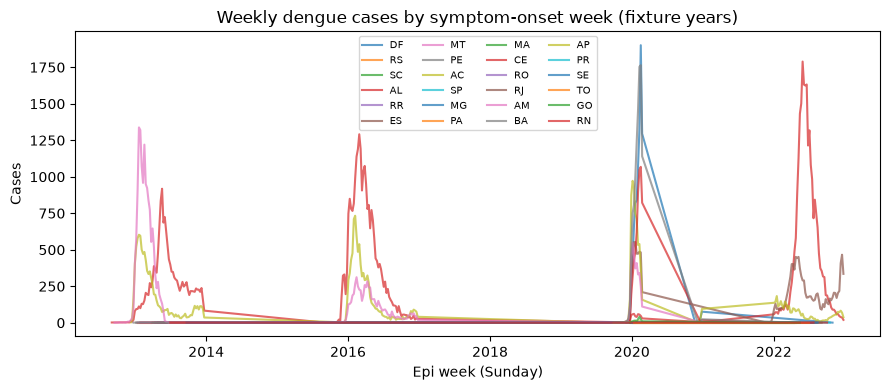

In [16]:
import matplotlib.pyplot as plt

weekly_totals = (
    series.group_by(["ew_symptom_onset", "state_abbrev"])
    .agg(pl.col("case_count").sum())
    .sort("ew_symptom_onset")
)

fig, ax = plt.subplots(figsize=(9, 4))
for state, group in weekly_totals.group_by("state_abbrev"):
    g = group.sort("ew_symptom_onset")
    ax.plot(g["ew_symptom_onset"], g["case_count"], label=state[0], alpha=0.7)

ax.set_title("Weekly dengue cases by symptom-onset week (fixture years)")
ax.set_xlabel("Epi week (Sunday)")
ax.set_ylabel("Cases")
ax.legend(fontsize=7, ncol=4)
fig.tight_layout()
plt.show()


## Integrity checks

Same checks the CLI and test suite run — schema, unique keys, positive counts,
Sunday-anchored weeks, onset ≤ notification, valid states, the `DT_DIGITA` gap,
and classification codes in range. `continuity_years` is skipped here since the
fixture years aren't contiguous.

Expect `states` to **fail** here: the fixtures are stratified samples and don't
carry every UF in every year. On the real 17-file input, this check passes.


In [17]:
from pipeline.sinan.integrity import run_all

for check in run_all(series, FU_PATH):
    print(check)


[PASS] schema: 6 columns in published order
[PASS] unique_keys: 12,496 rows, all keys distinct
[PASS] positive_counts: 159,400 cases total
[PASS] weeks_start_on_sunday: all epi-week dates are Sundays
[PASS] onset_not_after_notification: onset week <= notification week
[FAIL] states: never appear in the series: ['MS', 'PB', 'PI']
[PASS] dt_digita_gap: ew_recorded null across 2014-2020
[PASS] classification_domain: codes [0, 1, 2, 3, 5, 8, 10, 11, 12]


## Running it for real

This notebook mirrors `transform()` in `src/pipeline/sinan/transform.py`, which
runs the same 10 steps over all 17 real yearly files (~7 GB) and writes
`SINAN_dengue_cases.parquet` + `.csv.gz`:

```bash
uv run arboili transform sinan
```
